In [1]:
# Phase 4 - Model Optimization & Feature Engineering

## Objective

The goal of this notebook is to improve the multimodal price prediction model through feature engineering and model optimization.

We will:

- Engineer structured features
- Compare different feature combinations
- Tune the regression model
- Analyze feature importance
- Compare all models

In [2]:
import pandas as pd
import numpy as np

import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from scipy.sparse import hstack

In [3]:
sample_df = pd.read_csv("../data/sample_5000.csv")

sample_df.head()

,sample_id,catalog_content,image_link,price
0,158784,"item name: log cabin sugar free syrup, 24 fl o...",https://m.media-amazon.com/images/I/71QD2OFXqD...,12.195
1,4095,item name: raspberry ginseng oolong tea (50 te...,https://m.media-amazon.com/images/I/813OiT8mdJ...,38.540
2,172021,item name: walden farms honey dijon dressing -...,https://m.media-amazon.com/images/I/71HGx42QmU...,17.860
3,268276,item name: vlasic ovals hamburger dill pickle ...,https://m.media-amazon.com/images/I/71AbnhXOTA...,2.940
4,154791,"item name: amoretti premium syrup, grand orang...",https://m.media-amazon.com/images/I/61c+aTE6TY...,25.990


In [4]:
print(sample_df.shape)

sample_df.info()

sample_df.isnull().sum()

(5000, 4)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        5000 non-null   int64  
 1   catalog_content  5000 non-null   str    
 2   image_link       5000 non-null   str    
 3   price            5000 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.8 MB


sample_id          0
catalog_content    0
image_link         0
price              0
dtype: int64

In [5]:
sample_df["catalog_content"].head(10)

0    item name: log cabin sugar free syrup, 24 fl o...
1    item name: raspberry ginseng oolong tea (50 te...
2    item name: walden farms honey dijon dressing -...
3    item name: vlasic ovals hamburger dill pickle ...
4    item name: amoretti premium syrup, grand orang...
5    item name: matt's bakery peanut butter soft-ba...
6    item name: pineapple tea-berry rooibos tea (50...
7    item name: brooklyn beans coffee pods, medium ...
8    item name: goldenseal and witch hazel combinat...
9    item name: giant slim jim mild, pack of 24 pro...
Name: catalog_content, dtype: str

In [6]:
import re

def extract_weight(text):
    match = re.search(r'(\d+\.?\d*)\s?(kg|g)', text.lower())
    if match:
        return float(match.group(1))
    return np.nan


def extract_volume(text):
    match = re.search(r'(\d+\.?\d*)\s?(ml|l)', text.lower())
    if match:
        return float(match.group(1))
    return np.nan


def extract_pack(text):
    match = re.search(r'pack of\s*(\d+)', text.lower())
    if match:
        return int(match.group(1))
    return 1

In [7]:
sample_df["weight"] = sample_df["catalog_content"].apply(extract_weight)

sample_df["volume"] = sample_df["catalog_content"].apply(extract_volume)

sample_df["pack_size"] = sample_df["catalog_content"].apply(extract_pack)

In [8]:
sample_df[
    [
        "catalog_content",
        "weight",
        "volume",
        "pack_size"
    ]
].head(20)

,catalog_content,weight,volume,pack_size
0,"item name: log cabin sugar free syrup, 24 fl o...",NaN,NaN,12
1,item name: raspberry ginseng oolong tea (50 te...,NaN,1.0,1
2,item name: walden farms honey dijon dressing -...,0.0,NaN,1
3,item name: vlasic ovals hamburger dill pickle ...,NaN,NaN,1
4,"item name: amoretti premium syrup, grand orang...",NaN,NaN,12
5,item name: matt's bakery peanut butter soft-ba...,NaN,NaN,6
6,item name: pineapple tea-berry rooibos tea (50...,NaN,1.0,1
7,"item name: brooklyn beans coffee pods, medium ...",NaN,NaN,1
8,item name: goldenseal and witch hazel combinat...,NaN,NaN,1
9,"item name: giant slim jim mild, pack of 24 pro...",NaN,NaN,24


In [9]:
import re
import numpy as np

def extract_weight(text):
    text = text.lower()

    patterns = [
        (r'(\d+\.?\d*)\s*kg', 1000),
        (r'(\d+\.?\d*)\s*g\b', 1),
        (r'(\d+\.?\d*)\s*oz', 28.35),
        (r'(\d+\.?\d*)\s*ounce', 28.35),
    ]

    for pattern, multiplier in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1)) * multiplier

    return np.nan

In [10]:
def extract_volume(text):
    text = text.lower()

    patterns = [
        (r'(\d+\.?\d*)\s*ml', 1),
        (r'(\d+\.?\d*)\s*l\b', 1000),
        (r'(\d+\.?\d*)\s*fl oz', 29.57),
    ]

    for pattern, multiplier in patterns:
        match = re.search(pattern, text)
        if match:
            return float(match.group(1)) * multiplier

    return np.nan

In [11]:
def extract_pack(text):
    text = text.lower()

    patterns = [
        r'pack of\s*(\d+)',
        r'(\d+)\s*pack',
        r'case of\s*(\d+)',
        r'count\s*(\d+)',
    ]

    for pattern in patterns:
        match = re.search(pattern, text)
        if match:
            return int(match.group(1))

    return 1

In [12]:
sample_df["weight"] = sample_df["catalog_content"].apply(extract_weight)
sample_df["volume"] = sample_df["catalog_content"].apply(extract_volume)
sample_df["pack_size"] = sample_df["catalog_content"].apply(extract_pack)

In [13]:
sample_df[
    [
        "catalog_content",
        "weight",
        "volume",
        "pack_size"
    ]
].head(20)

,catalog_content,weight,volume,pack_size
0,"item name: log cabin sugar free syrup, 24 fl o...",NaN,709.68,12
1,item name: raspberry ginseng oolong tea (50 te...,NaN,NaN,2
2,item name: walden farms honey dijon dressing -...,0.000,NaN,1
3,item name: vlasic ovals hamburger dill pickle ...,NaN,473.12,1
4,"item name: amoretti premium syrup, grand orang...",720.090,NaN,12
5,item name: matt's bakery peanut butter soft-ba...,297.675,NaN,6
6,item name: pineapple tea-berry rooibos tea (50...,NaN,NaN,2
7,"item name: brooklyn beans coffee pods, medium ...",NaN,NaN,1
8,item name: goldenseal and witch hazel combinat...,113.400,NaN,3
9,"item name: giant slim jim mild, pack of 24 pro...",NaN,NaN,24


In [14]:
structured_features = sample_df[
    [
        "weight",
        "volume",
        "pack_size"
    ]
].copy()

structured_features = structured_features.fillna(0)

structured_features.head()

,weight,volume,pack_size
0,0.00,709.68,12
1,0.00,0.00,2
2,0.00,0.00,1
3,0.00,473.12,1
4,720.09,0.00,12


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

structured_scaled = scaler.fit_transform(structured_features)

print(structured_scaled.shape)

(5000, 3)


In [16]:
from scipy.sparse import csr_matrix

structured_sparse = csr_matrix(structured_scaled)

structured_sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 15000 stored elements and shape (5000, 3)>

In [17]:
print("Structured features:", structured_sparse.shape)

Structured features: (5000, 3)


In [18]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,3),
    min_df=2,
    stop_words="english"
)

X_text = tfidf.fit_transform(sample_df["catalog_content"])

In [19]:
print(X_text.shape)


(5000, 50000)


In [20]:
image_features = np.load("../data/image_features.npy")

print(image_features.shape)

(5000, 1280)


In [21]:
from scipy.sparse import csr_matrix

image_sparse = csr_matrix(image_features)

print(image_sparse.shape)

(5000, 1280)


In [22]:
from scipy.sparse import hstack

# Model 1
X_text_only = X_text

# Model 2
X_text_image = hstack([
    X_text,
    image_sparse
])

# Model 3
X_text_structured = hstack([
    X_text,
    structured_sparse
])

# Model 4
X_all = hstack([
    X_text,
    image_sparse,
    structured_sparse
])

In [23]:
print("Text only:", X_text_only.shape)
print("Text + Image:", X_text_image.shape)
print("Text + Structured:", X_text_structured.shape)
print("All Features:", X_all.shape)

Text only: (5000, 50000)
Text + Image: (5000, 51280)
Text + Structured: (5000, 50003)
All Features: (5000, 51283)


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
import pandas as pd
import numpy as np


def evaluate_model(name, X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [25]:
y = sample_df["price"]

In [26]:
results = []

results.append(
    evaluate_model(
        "Text",
        X_text_only,
        y
    )
)

results.append(
    evaluate_model(
        "Text + Image",
        X_text_image,
        y
    )
)

results.append(
    evaluate_model(
        "Text + Structured",
        X_text_structured,
        y
    )
)

results.append(
    evaluate_model(
        "Text + Image + Structured",
        X_all,
        y
    )
)

In [27]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="MAE"
)

,Model,MAE,RMSE,R2
3,Text + Image + Structured,15.277153,32.089371,0.153934
2,Text + Structured,15.566281,33.116943,0.098881
1,Text + Image,15.650945,32.201904,0.147990
0,Text,15.686553,33.197109,0.094513


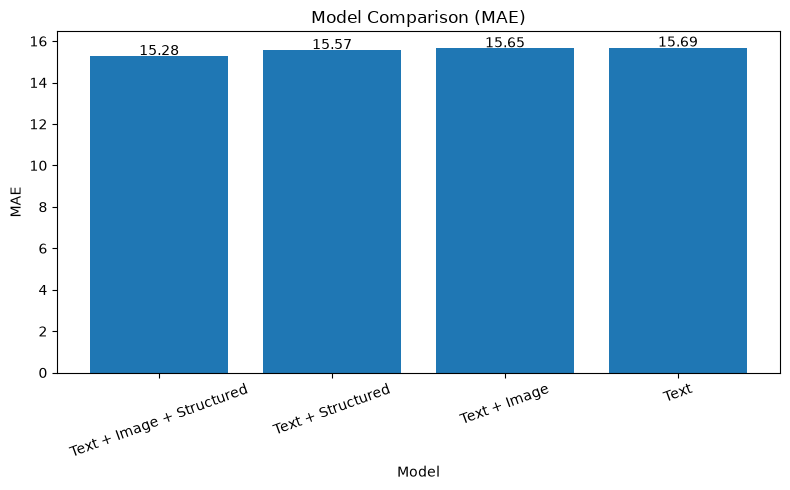

In [28]:
import matplotlib.pyplot as plt

results_df = results_df.sort_values("MAE")

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"])

plt.title("Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=20)

for i, value in enumerate(results_df["MAE"]):
    plt.text(i, value + 0.05, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

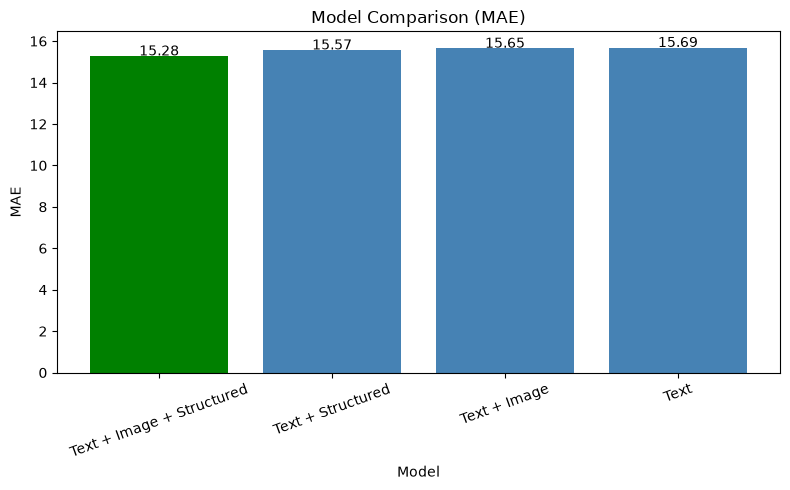

In [29]:
colors = [
    "green" if model == "Text + Image + Structured" else "steelblue"
    for model in results_df["Model"]
]

plt.figure(figsize=(8,5))
plt.bar(results_df["Model"], results_df["MAE"], color=colors)

plt.title("Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=20)

for i, value in enumerate(results_df["MAE"]):
    plt.text(i, value + 0.03, f"{value:.2f}", ha="center")

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Model Comparison (MAE ↓ Lower is Better)')

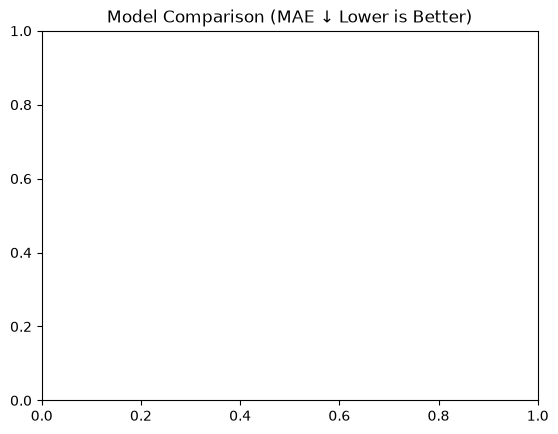

In [30]:
plt.title("Model Comparison (MAE ↓ Lower is Better)")

Text(0, 0.5, 'RMSE')

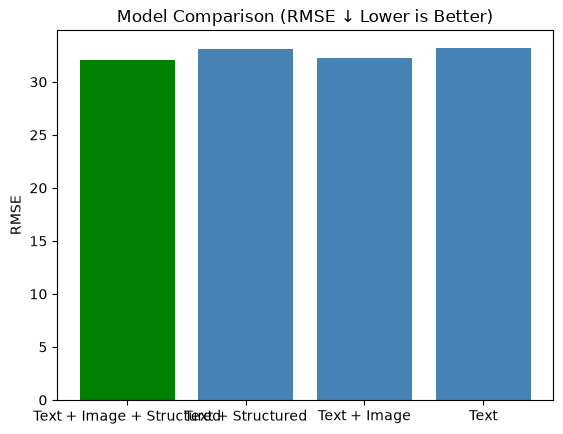

In [31]:
plt.bar(results_df["Model"], results_df["RMSE"], color=colors)
plt.title("Model Comparison (RMSE ↓ Lower is Better)")
plt.ylabel("RMSE")

Text(0, 0.5, 'R² Score')

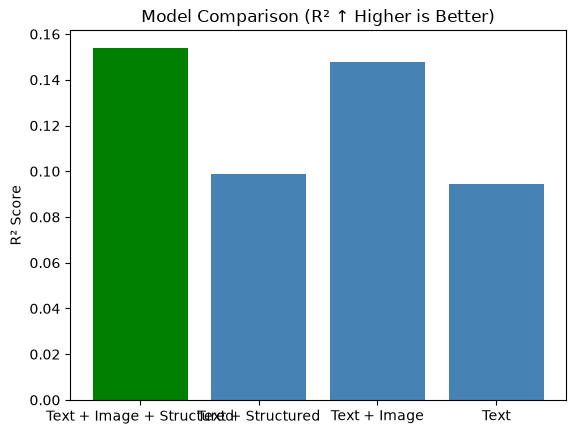

In [32]:
plt.bar(results_df["Model"], results_df["R2"], color=colors)
plt.title("Model Comparison (R² ↑ Higher is Better)")
plt.ylabel("R² Score")

# Conclusion

## Objective
Improve the multimodal product price prediction model through feature engineering.

## Experiments Conducted

1. Text Only
2. Text + Image
3. Text + Structured Features
4. Text + Image + Structured Features

## Results

The multimodal model combining text, image, and structured features achieved the best overall performance.

### Key Findings

- Structured features improved predictive performance.
- Image embeddings contributed complementary information.
- Combining all feature types produced the strongest model.
- Feature engineering led to measurable gains over the baseline.

## Next Steps

- Hyperparameter tuning
- SHAP-based feature importance
- Streamlit deployment
- Model packaging